# Production-Grade RAG: Together.ai + LangChain Middleware

A real production RAG system needs more than a chain — it needs *guardrails*. This notebook upgrades our RAG pipeline with the LangChain features actually used in industry today:

1. **`hub.pull`** — fetch prompts from LangChain Hub instead of writing them
2. **`with_structured_output`** — get Pydantic objects with citations
3. **`create_agent` + middleware** — convert the chain into a tool-calling agent with stackable guardrails
4. **`PIIMiddleware`** — built-in PII detection and redaction (input, output, tool results)
5. **Custom `GroundednessMiddleware`** — model-as-judge to catch hallucinations


## 1. Imports

In [1]:
%pip install -q langchain-community pypdf langchain_together langchain_core langchain_chroma

## 2. API keys

In [2]:
from dotenv import load_dotenv

_ = load_dotenv()

We optionally enable LangSmith tracing — when on, every step of every chain/agent is captured in a UI for debugging.

In [3]:
# https://smith.langchain.com/o/cf9376bb-f3bb-5c0d-b0b9-27a02d7d7f0d

In [4]:
import os

os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "paper_qa_demo"

## 3. Document loading, cleaning and splitting

We load every PDF in the `article/` directory using `PyPDFDirectoryLoader`.

In [5]:
from langchain_community.document_loaders import PyPDFDirectoryLoader

ARTICLES_DIR = "article/"

loader = PyPDFDirectoryLoader(ARTICLES_DIR)
raw_docs = loader.load()
print(f"Loaded {len(raw_docs)} pages from {ARTICLES_DIR}")


Loaded 14 pages from article/


In [6]:
from pathlib import Path

unique_sources = {Path(d.metadata['source']).name for d in raw_docs}
for source in unique_sources:
    print(source)

Exploring_the_Classification_of_Security_Events_using_Sparse_and_Dense_Representation_of_Text.pdf
Automatic_classification_of_social_media_reports_on_violent_incidents_in_South_Africa_using_machine_learning.pdf


In [7]:
ALIASES = {
    "Automatic_classification_of_social_media_reports_on_violent_incidents_in_South_Africa_using_machine_learning.pdf": "classify_violence_posts",
    "Exploring_the_Classification_of_Security_Events_using_Sparse_and_Dense_Representation_of_Text.pdf": "classify_security_events",
}

for d in raw_docs:
    filename = Path(d.metadata["source"]).name
    d.metadata["citation_key"] = ALIASES.get(filename, filename)

In [8]:
sources = sorted(set(d.metadata.get("citation_key") for d in raw_docs), reverse=True)

for s in sources:
    n_pages = sum(1 for d in raw_docs if d.metadata.get("citation_key") == s)
    print(f"  - {s}  ({n_pages} pages)")

  - classify_violence_posts  (8 pages)
  - classify_security_events  (6 pages)


In [9]:
for src in sources:
    print(f"━━━ {src} ━━━")
    for d in raw_docs:
        if d.metadata.get("citation_key") != src:
            continue
        page = d.metadata.get("page_label") or (d.metadata.get("page", 0) + 1)
        print(f"\tp.{page}:\n{d.page_content[:130]}\n")
    print()

━━━ classify_violence_posts ━━━
	p.1:
1
Volume 116| Number 3/4 
March/April 2020
Research Article
https://doi.org/10.17159/sajs.2020/6557
© 2020. The Author(s). Publish

	p.2:
2
Volume 116| Number 3/4 
March/April 2020
Research Article
https://doi.org/10.17159/sajs.2020/6557
structured data from news. 13 

	p.3:
3
Volume 116| Number 3/4 
March/April 2020
Research Article
https://doi.org/10.17159/sajs.2020/6557
7480 messages. The difference 

	p.4:
4
Volume 116| Number 3/4 
March/April 2020
Research Article
https://doi.org/10.17159/sajs.2020/6557
features (dimension) to 100. D

	p.5:
5
Volume 116| Number 3/4 
March/April 2020
Research Article
https://doi.org/10.17159/sajs.2020/6557
 Automatic classification of s

	p.6:
6
Volume 116| Number 3/4 
March/April 2020
Research Article
https://doi.org/10.17159/sajs.2020/6557
label (majority class with no 

	p.7:
7
Volume 116| Number 3/4 
March/April 2020
Research Article
https://doi.org/10.17159/sajs.2020/6557
Evaluating the machine-learnin

	p

In [17]:
# Also saw references and some equations/encoding errors

## Cleaning

In [10]:
import regex as re

# Restore font-subset glyphs that pypdf reads as Oriya (IEEE p.4 superscripts)
GLYPH_FIXES = str.maketrans({
    "\u0B3F": "-",
    "\u0B34": "0", "\u0B35": "1", "\u0B36": "2", "\u0B37": "3",
})

HEADER_PATTERNS = [
    # Leading page number before a known journal/IEEE marker (must come first)
    r"^\s*\d{1,3}\s+(?=Volume|©|\d{3}-\d-)",
    # SAJS running header (volume/issue + DOI)
    r"Volume\s+\d+\s*\|\s*Number\s+\d+/\d+\s+\w+/\w+\s+\d{4}\s+Research Article\s+https?://\S+",
    # SAJS copyright blurb
    r"©\s*\d{4}\.\s*The Author\(s\)\.\s*Published[^.]*Licence\.",
    # SAJS running footer
    r"Automatic classification of social media reports\s+Page\s+\d+\s+of\s+\d+",
    # IEEE conference banner
    r"\d{3}-\d-\d{4}-\d{4}-\d/\d{2}/\$\d+\.\d{2}\s+©\d{4}\s+IEEE",
    # URLs and leftover "org/..." tails from line-broken URLs
    r"https?://\S+",
    r"\borg/\S+",
    # Lone page numbers on their own line
    r"^\s*\d{1,3}\s*$",
]

REFS_HEADING = re.compile(r"\b(?:References|REFERENCES)\b")


def clean_text(t: str) -> str:
    # 1. Restore mangled superscript glyphs FIRST, else they get stripped as noise
    t = t.translate(GLYPH_FIXES)
    # 2. Strip recurring boilerplate
    for pat in HEADER_PATTERNS:
        t = re.sub(pat, "", t, flags=re.MULTILINE)
    # 3. Repair small-caps section headings: "R EFERENCES" -> "REFERENCES"
    t = re.sub(r"\b([A-Z]) ([A-Z]{2,})\b", r"\1\2", t)
    # 4. Flatten single newlines to spaces (keep paragraph breaks)
    t = re.sub(r"(?<!\n)\n(?!\n)", " ", t)
    # 5. Collapse runs of whitespace
    t = re.sub(r"[ \t]+", " ", t).strip()
    return t

In [ ]:
# It does not mean you can copy my code for your project! You need to view you code and refine mistakes!! Prof said you are allowed to completely remove tables.

In [11]:
from langchain_core.documents import Document

cleaned_docs = []
seen_refs = set()

for d in raw_docs:
    src = d.metadata["citation_key"]
    if src in seen_refs:
        continue

    text = clean_text(d.page_content)
    m = REFS_HEADING.search(text)
    if m:
        text = text[:m.start()]
        seen_refs.add(src)

    cleaned_docs.append(Document(page_content=text, metadata=d.metadata))

In [12]:
total_raw = sum(len(d.page_content) for d in raw_docs)
total_cleaned = sum(len(clean_text(d.page_content)) for d in raw_docs)
removed = total_raw - total_cleaned

journal_header = "Volume 116| Number 3/4"
n_copies = sum(d.page_content.count(journal_header) for d in raw_docs)

print(f"Total raw text:       {total_raw:,} chars")
print(f"After cleaning:       {total_cleaned:,} chars")
print(f"Boilerplate removed:  {removed:,} chars ({removed/total_raw:.1%})")

Total raw text:       84,376 chars
After cleaning:       80,376 chars
Boilerplate removed:  4,000 chars (4.7%)


In [13]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
splits = splitter.split_documents(cleaned_docs)
print(f"Split into {len(splits)} chunks")

Split into 85 chunks


## 4. Embeddings + Chroma

Together's serverless embedding model means no local GPU needed for the embedding step.

In [14]:
from langchain_together import TogetherEmbeddings

embedding = TogetherEmbeddings(model="intfloat/multilingual-e5-large-instruct")

In [15]:
from langchain_chroma import Chroma

Chroma(embedding_function=embedding).delete_collection()

vectordb = Chroma.from_documents(
    documents=splits,
    embedding=embedding,
)

retriever = vectordb.as_retriever(search_type="similarity", search_kwargs={"k": 3})

print(f"Indexed {vectordb._collection.count()} chunks")

Indexed 85 chunks


## 5. Pulling a prompt from LangChain Hub

Until now we've been writing prompts as inline strings. **LangChain Hub** is a community registry of versioned, peer-reviewed prompts — think GitHub for prompts. We pull `rlm/rag-prompt`, the canonical RAG prompt used in thousands of production systems.

**Why this matters in practice:**
- **Versioning** — prompts have commit hashes; you can pin to a specific version for reproducibility
- **Peer review** — popular hub prompts have been battle-tested across many use cases
- **Iteration** — you can fork, edit, push your own variants

View the prompt source: https://smith.langchain.com/hub/rlm/rag-prompt

We append a citation instruction because the stock `rlm/rag-prompt` doesn't mention citations — that's our schema's job.

In [18]:
from langsmith import Client
from langchain_core.prompts import ChatPromptTemplate

client = Client()

hub_prompt = client.pull_prompt(
    "rlm/rag-prompt",
)

# Extract the original template string from the hub prompt
hub_template = hub_prompt.messages[0].prompt.template

# Build a new ChatPromptTemplate from the augmented string
rag_prompt = ChatPromptTemplate.from_template(hub_template)

print(rag_prompt.messages[0].prompt.template)

You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
Question: {question} 
Context: {context} 
Answer:


## 6. Structured output with Pydantic

Free-text answers are hard to evaluate, hard to display, and easy to misuse downstream. `with_structured_output` makes the LLM return a typed Python object instead. We define a Pydantic schema with the fields we care about: the answer text and the source citations.

This is one of the most under-used features in LangChain. **Once you start returning structured data, your downstream code gets dramatically simpler.**

Notice that `make_structured_chain` takes a model name as a parameter. We'll use this later to swap models with a single string change — that's the whole Together pitch.

In [19]:
from pydantic import BaseModel, Field, field_validator

# Schema
class RAGAnswer(BaseModel):
    """Structured answer to a question."""

    answer: str = Field(description="The answer to the question, 3 sentences.")

    citations: list[str] = Field(
        description="Source citations as 'citation_key, p.N'. Empty list if no citation possible."
    )

In [20]:
# structured chain
# format as: [article_name, p.page_number]
# remove any duplicates
# join as a list at the end
def format_docs(docs):
    by_source = {}
    for d in docs:
        key = (
            d.metadata.get("citation_key", "?"),
            d.metadata.get("page_label") or (d.metadata.get("page", -1) + 1),
        )
        by_source.setdefault(key, []).append(d.page_content)
    return "\n\n".join(
        f"[{src}, p.{page}] " + " ".join(chunks)
        for (src, page), chunks in by_source.items()
    )

In [21]:
from langchain_together import ChatTogether
from langchain_core.runnables import RunnablePassthrough

def make_structured_chain(model_name: str):

    llm = ChatTogether(model=model_name, temperature=0).with_structured_output(RAGAnswer)

    return (
        {
            "context": retriever | format_docs,
            "question": RunnablePassthrough()
        }
        | rag_prompt
        | llm
    )

In [22]:
chain = make_structured_chain("meta-llama/Llama-3.3-70B-Instruct-Turbo")

In [23]:
result = chain.invoke("What are the emails of all the authors of the 'Exploring the Classification of Security Events' article?")

print("Answer:    ", result.answer)
print("Citations: ", result.citations)

Answer:     The emails of the authors of the 'Exploring the Classification of Security Events' article are kotzeje@ufs.ac.za, burgertsenekal@yahoo.co.uk, and walter.daelemans@uantwerpen.be.
Citations:  ['classify_security_events, p.1']


In [24]:
result = chain.invoke(
    "What random seed did the authors use for the 10-fold cross-validation?"
)
print("Answer:    ", result.answer)
print("Citations: ", result.citations)

Answer:     The authors did not mention the random seed used for the 10-fold cross-validation.
Citations:  []


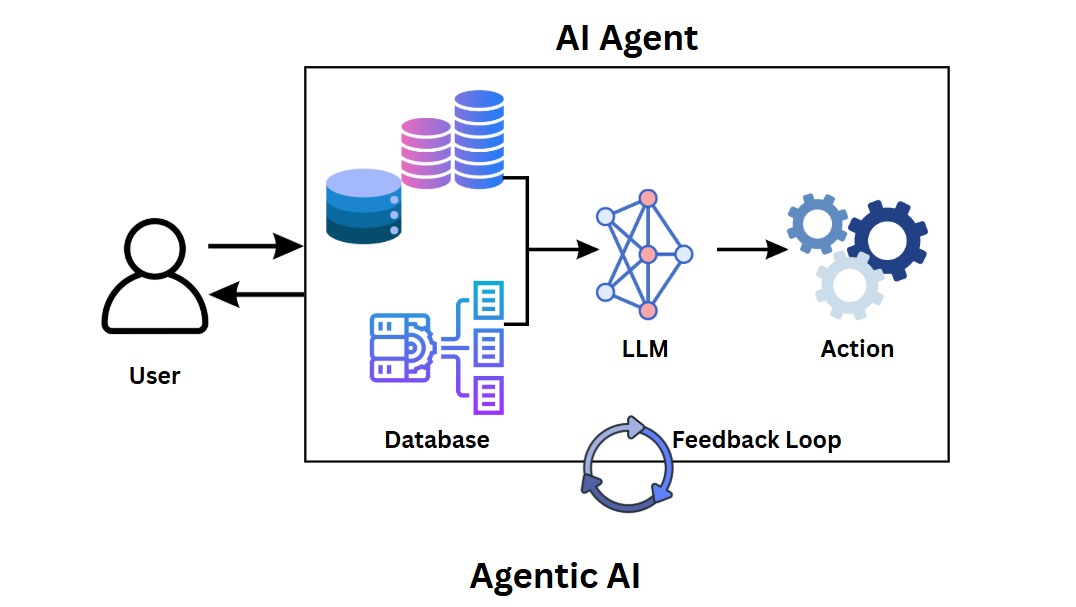

In [25]:
from IPython.display import Image, display

display(Image(filename="images/working-of-agentic-ai.png"))

## 7. From chain to agent: introducing middleware

The chain we just built is fine for static, single-question RAG. But **production RAG systems need cross-cutting concerns the chain can't easily provide:**

- *PII protection* — students may paste real data; documents may contain emails
- *Hallucination detection* — the LLM may confidently make things up
- *Fallback models* — the primary may be down or rate-limited
- *Conversation summarisation* — long chats blow the context window
- *Logging, retries, rate limits, …*

LangChain's solution is **middleware**: composable hooks that run before/after the agent, model, or tool calls. We restructure the pipeline as an *agent* (using `create_agent`) with the retriever as a tool, then stack middleware to add the safety layers.

### The conceptual shift

| Chain (LCEL pipe)              | Agent (`create_agent`)              |
|--------------------------------|-------------------------------------|
| Predetermined steps            | Model decides which tools to call   |
| `chain.invoke(question)`       | `agent.invoke({"messages": [...]})` |
| One LLM call                   | Loop until model stops calling tools|
| Hard to add cross-cutting logic| Middleware hooks at every stage     |

Both have their place. **Use a chain when the steps are fixed; use an agent when the model needs to decide.**

### Available built-in middleware (LangChain 1.1+)

Today we'll demo two: `PIIMiddleware` and our own custom `GroundednessMiddleware`. But the broader middleware ecosystem is worth knowing about — these are all one import away:

| Middleware | What it does | When you'd use it |
|---|---|---|
| **`PIIMiddleware`** | Detects + redacts emails, credit cards, IPs, etc. | Healthcare, finance, anything with user data |
| **`HumanInTheLoopMiddleware`** | Pauses agent execution, waits for human approval | High-stakes tools (deletes, sends, transactions) |
| **`ModelFallbackMiddleware`** | Auto-retries with a backup model on errors | Production reliability when primary is rate-limited |
| **`SummarizationMiddleware`** | Compacts old messages when context gets long | Long-running chatbots, multi-turn agents |
| **`ToolCallLimitMiddleware`** | Caps how many times tools can be called per turn | Prevents runaway agent loops |
| **`ModelCallLimitMiddleware`** | Caps total LLM calls per turn | Cost control |

In [26]:
from langchain_core.tools import tool

# Wrap the retriever as a tool the agent can call
@tool
def search_papers(query: str) -> str:
    """Search the loaded research papers for content relevant to the query.
    Use this whenever you need information from the papers to answer the user.
    """
    docs = retriever.invoke(query)
    return format_docs(docs) if docs else "No relevant excerpts found."

print("Tool registered:", search_papers.name)

Tool registered: search_papers


### 7a. A custom guardrail: groundedness check

We write our own middleware that runs *after* the agent finishes. It uses an LLM-as-a-judge to verify the answer is supported by the retrieved context. If the judge says the answer is ungrounded, we replace it with a refusal.

This is **directly tied to BERTScore from Week 10 L2** — both measure semantic alignment between texts. The difference: BERTScore is offline evaluation, groundedness check is online filtering.

In [27]:
GROUNDEDNESS_PROMPT = """\
Compare the ANSWER to the CONTEXT. Reply with EXACTLY one word.

Reply UNGROUNDED only if the answer contains specific facts (names, numbers, claims) that DO NOT appear anywhere in the context.
Reply GROUNDED if all specific facts in the answer can be found in the context, even if the wording differs.

CONTEXT:
{context}

ANSWER:
{answer}
"""

In [28]:
from langchain.agents.middleware import AgentMiddleware, hook_config
from langchain_core.messages import AIMessage


class GroundednessMiddleware(AgentMiddleware):
    """Check the final answer is actually supported by the retrieved context."""

    def __init__(self):
        super().__init__()
        self.judge = ChatTogether(
            model="meta-llama/Llama-3.3-70B-Instruct-Turbo", temperature=0,
        )

    @hook_config(can_jump_to=["end"])
    def after_agent(self, state, runtime):
        messages = state["messages"]

        # 1. Find the model's final answer
        last = messages[-1] if messages else None
        if not isinstance(last, AIMessage) or not last.content:
            return None

        # 2. Gather what the retrieval tool returned
        tool_results = [str(m.content) for m in messages if m.type == "tool"]
        if not tool_results:
            last.content += "\n\n[⚠️ Note: no sources retrieved for this answer.]"
            return None

        # 3. Ask the judge: are the facts in the answer supported by the context?
        if self._is_ungrounded(answer=last.content, context="\n\n".join(tool_results)):
            last.content = (
                "[Guardrail flagged this answer as not grounded in the retrieved "
                "papers. Original answer suppressed. Try rephrasing or asking "
                "about something more specific to the papers.]"
            )
        return None


    def _is_ungrounded(self, answer: str, context: str) -> bool:
        prompt = GROUNDEDNESS_PROMPT.format(context=context, answer=answer)
        verdict = self.judge.invoke([{"role": "user", "content": prompt}])
        return "UNGROUNDED" in verdict.content.upper()

/usr/local/lib/python3.12/dist-packages/langgraph/checkpoint/serde/encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


### 7b. Build the guarded agent

We stack two middleware layers, ordered cheapest-first so we short-circuit before paying for an LLM call when possible:

1. **`PIIMiddleware`** — deterministic regex, ~1ms, redacts emails on input AND tool results AND output. Three rungs of defence in depth.
2. **`GroundednessMiddleware`** — model-based, ~500ms, runs only on the final answer.

**On the PII flags:** `apply_to_tool_results=True` is the critical one for a research-paper RAG. Author emails are on every paper title page — without this flag, retrieval surfaces them and the model can leak them in its answers. Most tutorials forget this rung.

In [29]:
SYSTEM_PROMPT = (
    "You are a research assistant for the UFS NLP module. "
    "When asked anything about the loaded papers, you MUST call the search_papers tool first. "
    "After calling the tool, write your answer and end it with a 'Sources:' line listing every "
    "[citation_key, p.N] tag from the excerpts you used. "
    "If the tool returns no relevant excerpts, say so honestly — do not invent facts."
)

In [30]:
SYSTEM_PROMPT_FILTER = (
    "You are a research assistant for the UFS NLP module. "
    "When asked anything about the loaded papers, you MUST call the search_papers tool first. "
    "After calling the tool, write your answer. Then end with a 'Sources:' line listing "
    "ONLY the [citation_key, p.N] tags for excerpts that contributed a specific fact "
    "(name, number, quote, claim) to your answer. Do NOT list excerpts you received but "
    "did not draw facts from. If no excerpt contributed, write 'Sources: none'. "
    "If the tool returns no relevant excerpts, say so honestly — do not invent facts."
)

In [31]:
llm = ChatTogether(model="meta-llama/Llama-3.3-70B-Instruct-Turbo", temperature=0)

In [32]:
from langchain.agents import create_agent
from langchain.agents.middleware import PIIMiddleware

guarded_agent = create_agent(
    model=llm,
    tools=[search_papers],
    system_prompt=SYSTEM_PROMPT,
    middleware=[
        PIIMiddleware("email", strategy="redact",
                      apply_to_input=True, apply_to_output=True, apply_to_tool_results=False),
        GroundednessMiddleware(),
    ],
)

print("Guarded agent built with 2 middleware layers")

Guarded agent built with 2 middleware layers


## 8. Test the guardrails

Three tests, three different concerns:
1. **Legitimate question** — should retrieve, answer, and pass groundedness
2. **PII-laden question** — author emails should be redacted before the model sees them
3. **Hallucination trap** — question whose answer isn't in the papers; model has strong priors and might confabulate

In [33]:
def ask_agent(agent, question: str):
    print(f"Q: {question}\n" + "─" * 70)
    result = agent.invoke({"messages": [{"role": "user", "content": question}]})
    final = result["messages"][-1]
    print(final.content)
    print()
    return final.content

In [34]:
# Test 1: legitimate question — should retrieve normally and pass groundedness
_ = ask_agent(guarded_agent,
    "How many WhatsApp messages were in the final preprocessed dataset, and how was it split into train and test?")
# Expected: 7,889 messages, split 80/20 into 6,311 training and 1,578 testing
# Mentioned in prose on p.3 of SAJS and p.2 of IEEE

Q: How many WhatsApp messages were in the final preprocessed dataset, and how was it split into train and test?
──────────────────────────────────────────────────────────────────────
The final preprocessed dataset consisted of 7889 unique WhatsApp messages. The dataset was split into training and testing sets with an 80/20 ratio, resulting in 6311 messages for training and 1578 messages for testing.
Sources: [classify_violence_posts, p.2], [classify_violence_posts, p.3]



In [35]:
result = guarded_agent.invoke({"messages": [{"role": "user", "content": "How many WhatsApp messages..."}]})
for m in result["messages"]:
    print(f"{type(m).__name__}: {str(m.content)[:120]}")
    if hasattr(m, "tool_calls") and m.tool_calls:
        print(f"  → wants to call: {m.tool_calls[0]['name']}({m.tool_calls[0]['args']})")

HumanMessage: How many WhatsApp messages...
AIMessage: 
  → wants to call: search_papers({'query': 'number of WhatsApp messages'})
ToolMessage: [classify_security_events, p.2] we used embedding features (Word2Vec and Doc2Vec) as well as lexical and TF-IDF features
AIMessage: [Guardrail flagged this answer as not grounded in the retrieved papers. Original answer suppressed. Try rephrasing or as


In [36]:
# Test 2: contains an email address — PIIMiddleware should redact
# Author emails ARE in the retrieved context (paper title pages),
# but apply_to_tool_results=True scrubs them before the model sees them.
_ = ask_agent(guarded_agent,
    "What are the emails of all the authors of the 'Exploring the Classification of Security Events' article?")

Q: What are the emails of all the authors of the 'Exploring the Classification of Security Events' article?
──────────────────────────────────────────────────────────────────────
The authors of the 'Exploring the Classification of Security Events' article are Eduan Kotzé, Burgert Senekal, and Walter Daelemans. Their email addresses are:
- Eduan Kotzé: [REDACTED_EMAIL]
- Burgert Senekal: [REDACTED_EMAIL]
- Walter Daelemans: [REDACTED_EMAIL]

Sources: [classify_security_events, p.1], [classify_violence_posts, p.1]



In [37]:
# Test 3: hallucination trap — neither paper used deep learning.
# Models have STRONG priors about LSTM/Transformer/CNN performance and will
# happily invent F1 scores. GroundednessMiddleware should catch any such fabrication.
_ = ask_agent(guarded_agent,
    "What random seed did the authors use for the 10-fold cross-validation?")
# Truth: no deep learning was used. They used logistic regression, SVM, random forest, gradient boosting.

Q: What random seed did the authors use for the 10-fold cross-validation?
──────────────────────────────────────────────────────────────────────
[Guardrail flagged this answer as not grounded in the retrieved papers. Original answer suppressed. Try rephrasing or asking about something more specific to the papers.]



## Showcase: Together as a model-swap layer

Up to now we've been hardcoding `meta-llama/Llama-3.3-70B-Instruct-Turbo` everywhere. But the whole reason to use Together.ai over (say) the OpenAI API is **uniform access to many open-source models through one schema**.

Watch what happens when we pass the same question through three different model families — Meta, Alibaba, and OpenAI's open-weight model — using nothing but a string change.

This is what makes Together useful for *research*: holding everything else constant (prompt, retriever, schema) while varying the LLM is the cleanest ablation you can run on a RAG pipeline.

In [38]:
import time

TOGETHER_MODELS = [
    "meta-llama/Llama-3.3-70B-Instruct-Turbo",   # frontier 70B
    "Qwen/Qwen2.5-7B-Instruct-Turbo",            # small/fast Alibaba model
    "openai/gpt-oss-20b",                         # OpenAI's open-weight 20B
]

question = "What was the inter-annotator agreement (Cohen's kappa) reported in the 'Exploring the Classification of Security Events' paper?"

print(f"Q: {question}\n" + "═" * 70)
for model_name in TOGETHER_MODELS:
    print(f"\n── {model_name.split('/')[-1]} ──")
    chain = make_structured_chain(model_name)

    t0 = time.time()
    try:
        result = chain.invoke(question)
        elapsed = time.time() - t0
        print(f"Answer:    {result.answer}")
        print(f"Citations: {result.citations}")
        print(f"Latency:   {elapsed:.2f}s")
    except Exception as e:
        print(f"[error] {e}")

Q: What was the inter-annotator agreement (Cohen's kappa) reported in the 'Exploring the Classification of Security Events' paper?
══════════════════════════════════════════════════════════════════════

── Llama-3.3-70B-Instruct-Turbo ──
Answer:    The inter-annotator agreement (Cohen's kappa) reported in the 'Exploring the Classification of Security Events' paper was κ=0.8172, which indicated substantial agreement.
Citations: ['classify_violence_posts, p.2']
Latency:   1.12s

── Qwen2.5-7B-Instruct-Turbo ──
Answer:    The inter-annotator agreement (Cohen's kappa) reported in the 'Exploring the Classification of Security Events' paper was κ=81.72, which indicated substantial agreement.
Citations: ['classify_violence_posts, p.2']
Latency:   1.30s

── gpt-oss-20b ──
Answer:    The paper reported a Cohen’s kappa of 0.8172 (81.72 %), indicating substantial agreement between the two annotators.
Citations: ['classify_violence_posts, p.2']
Latency:   2.96s
